# EDA AND PREPROCESSING

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/drive/MyDrive/DATA SCIENCE /Data Set/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


There is no missing value in data

In [6]:
# delete customerID as it is irrevelent for prediction
df = df.drop('customerID', axis=1)

In [7]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


There are 17 categorical/Ordinal Features  and 3 Numeric Features and Churn is dependent Feature

<Axes: ylabel='tenure'>

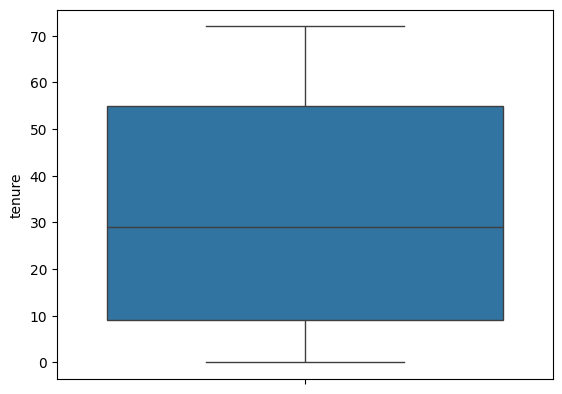

In [8]:
sns.boxplot(df['tenure'])

Tenure column doesn't have any outlier

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [11]:
df['TotalCharges']=df['TotalCharges'].replace(' ',0)

In [15]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [16]:
df['TotalCharges'].dtype

dtype('float64')

Total Charges numeric values were stored as string values so it converted to numeric

<Axes: ylabel='MonthlyCharges'>

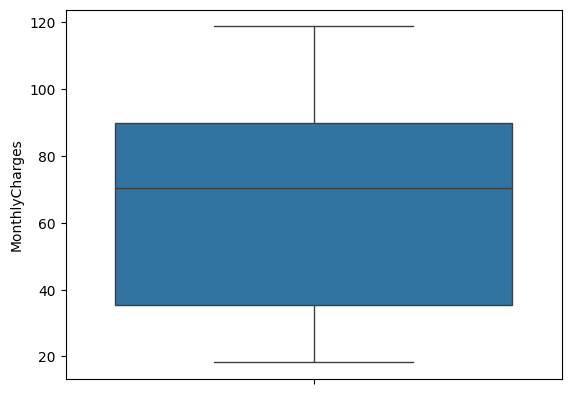

In [17]:
sns.boxplot(df['MonthlyCharges'])

Monthly charges is in the normal range

<Axes: ylabel='TotalCharges'>

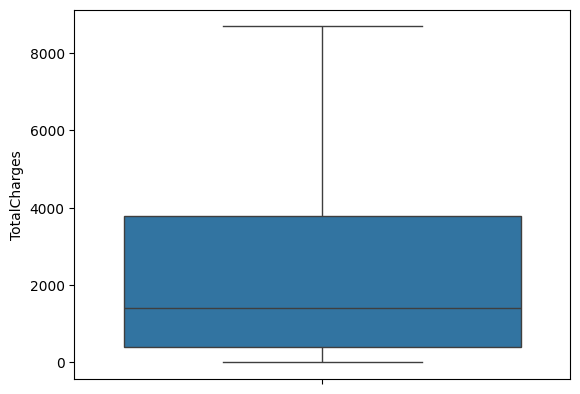

In [18]:
sns.boxplot(df['TotalCharges'])

Total charges are in normal range

<Axes: xlabel='gender', ylabel='count'>

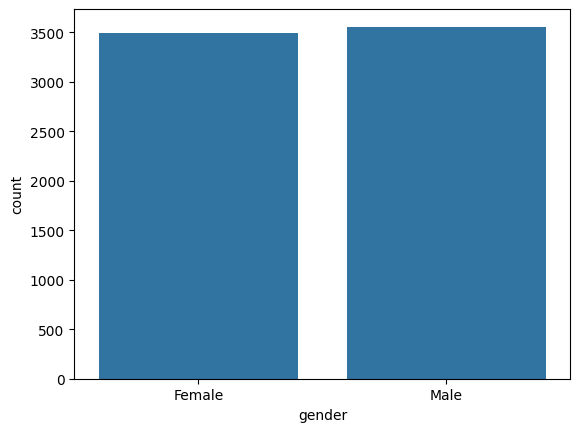

In [19]:
sns.countplot(x=df['gender'])

The count of male and females are almost same

<Axes: xlabel='SeniorCitizen', ylabel='count'>

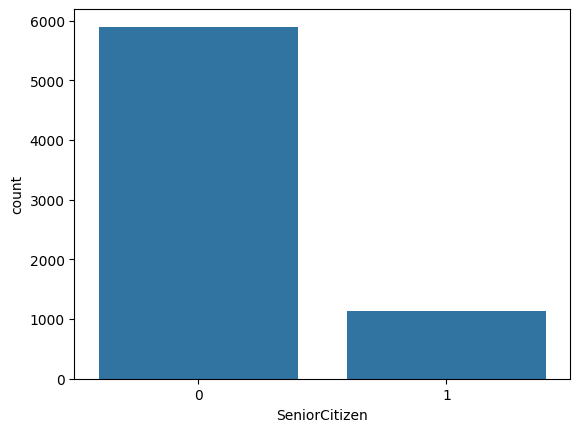

In [21]:
sns.countplot(x=df['SeniorCitizen'])

There are around 1200 senior citizen.

<Axes: xlabel='MultipleLines', ylabel='count'>

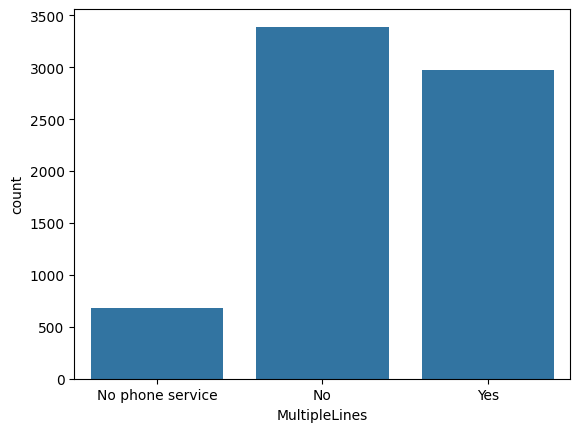

In [22]:
sns.countplot(x=df['MultipleLines'])

Majority people have Phone service but around half of them doesn't have multiple lines.

<Axes: xlabel='Partner', ylabel='count'>

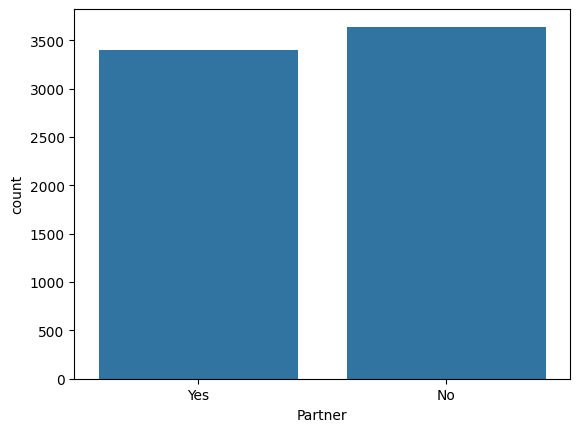

In [23]:
sns.countplot(x=df['Partner'])

Partner column is almost balanced.

<Axes: xlabel='Dependents', ylabel='count'>

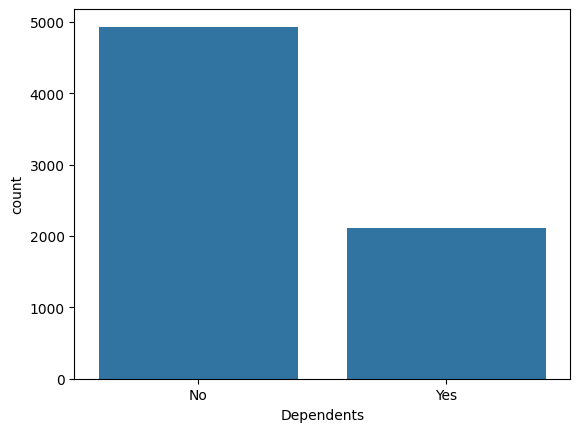

In [24]:
sns.countplot(x=df['Dependents'])

Majority customers does not have dependents.

In [25]:
df['DeviceProtection'].value_counts()

,count
DeviceProtection,
No,3095
Yes,2422
No internet service,1526


3095 customers are not using any device protection and 2422 are using it and 1526 doesn't have internet service.

In [26]:
df['OnlineSecurity'].value_counts()

,count
OnlineSecurity,
No,3498
Yes,2019
No internet service,1526


3498 customers are not using any Online Security and 2019 are using it

In [27]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [28]:
1869/7043*100

26.536987079369588

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [30]:
for i in df.columns:
  if(df[i].dtypes=='object'):
    df[i]=le.fit_transform(df[i])

In [31]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


In [32]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [33]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=123,test_size=0.3,stratify=y)

# MODEL SELECTION

1. We will implement Logestic Regression As y is binary.
2. We will implement Decision tree as majority Independent features are categorical.
3. We will implement Random forest as there are plenty rows.
4. The data is around 25% NO and 75% YES class of churn, which is imbalance so we will try with and without balancing it.

# Under Sampling Data preperation

In [37]:
from imblearn.under_sampling import NearMiss

nm=NearMiss()
X_us,y_us=nm.fit_resample(X,y)

In [38]:
X_us.shape

(3738, 20)

In [39]:
X_train_us,X_test_us,y_train_us,y_test_us=train_test_split(X_us,y_us,random_state=123,test_size=0.3,stratify=y_us)

In [43]:
# Over sampling Data preperation

from imblearn.over_sampling import SMOTE

sm=SMOTE()

X_os,y_os=sm.fit_resample(X,y)

X_train_os,X_test_os,y_train_os,y_test_os=train_test_split(X_os,y_os,random_state=123,test_size=0.3,stratify=y_os)

In [42]:
X_os.shape

(10348, 20)

This is the part of EDA only

# Logestic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr=LogisticRegression()

In [46]:
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_pred=lr.predict(X_test)

In [48]:
from sklearn.metrics import confusion_matrix,classification_report

In [49]:
print(confusion_matrix(y_test,y_pred))

[[1390  162]
 [ 262  299]]


In [50]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1552
           1       0.65      0.53      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [51]:
# train with under sampling data
lr.fit(X_train_us,y_train_us)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [53]:
y_pred_us=lr.predict(X_test_us)

In [54]:
print(classification_report(y_test_us,y_pred_us))

              precision    recall  f1-score   support

           0       0.69      0.60      0.64       561
           1       0.64      0.73      0.68       561

    accuracy                           0.66      1122
   macro avg       0.67      0.66      0.66      1122
weighted avg       0.67      0.66      0.66      1122



In [55]:
# training with Over sampling
lr.fit(X_train_os,y_train_os)
y_pred_os=lr.predict(X_test_os)
print(classification_report(y_test_os,y_pred_os))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1553
           1       0.78      0.81      0.80      1552

    accuracy                           0.79      3105
   macro avg       0.79      0.79      0.79      3105
weighted avg       0.79      0.79      0.79      3105



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Decision tree

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
dt=DecisionTreeClassifier()

In [58]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [59]:
y_pred=dt.predict(X_test)

In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1552
           1       0.46      0.47      0.47       561

    accuracy                           0.71      2113
   macro avg       0.63      0.64      0.64      2113
weighted avg       0.72      0.71      0.71      2113



In [62]:
# training with under sampling
dt.fit(X_train_us,y_train_us)
y_pred_us=dt.predict(X_test_us)
print(classification_report(y_test_us,y_pred_us))

              precision    recall  f1-score   support

           0       0.62      0.60      0.61       561
           1       0.61      0.64      0.63       561

    accuracy                           0.62      1122
   macro avg       0.62      0.62      0.62      1122
weighted avg       0.62      0.62      0.62      1122



In [63]:
# training with oversampling
dt.fit(X_train_os,y_train_os)
y_pred_os=dt.predict(X_test_os)
print(classification_report(y_test_os,y_pred_os))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      1553
           1       0.80      0.79      0.79      1552

    accuracy                           0.79      3105
   macro avg       0.79      0.79      0.79      3105
weighted avg       0.79      0.79      0.79      3105



# Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf=RandomForestClassifier()

In [66]:
param={'n_estimators':[50,100,120,150],
       'bootstrap':[True,False],
       'max_depth':[3,4,5,6,8],
}

In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
gsc= GridSearchCV(estimator=rf,param_grid=param,scoring='accuracy')

In [69]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [3, 4, 5, 6, 8],
                         'n_estimators': [50, 100, 120, 150]},
             scoring='accuracy')

In [71]:
y_pred=gsc.best_estimator_.predict(X_test)

In [73]:
# oversampling
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1552
           1       0.67      0.44      0.53       561

    accuracy                           0.79      2113
   macro avg       0.75      0.68      0.70      2113
weighted avg       0.78      0.79      0.78      2113



In [75]:
# Random Forest With Undrsampling
gsc.fit(X_train_us,y_train_us)
gsc.best_estimator_.fit(X_train_us,y_train_us)
y_pred_us=gsc.best_estimator_.predict(X_test_us)

print(classification_report(y_test_us,y_pred_us))

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       561
           1       0.66      0.72      0.69       561

    accuracy                           0.67      1122
   macro avg       0.68      0.67      0.67      1122
weighted avg       0.68      0.67      0.67      1122



In [76]:
gsc.fit(X_train_os,y_train_os)
gsc.best_estimator_.fit(X_train_os,y_train_os)
y_pred_os=gsc.best_estimator_.predict(X_test_os)

print(classification_report(y_test_os,y_pred_os))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1553
           1       0.81      0.87      0.84      1552

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105



# CONCLUSION:


The Data is About Telecom Customers , and y is churn.there are 7043 rows and 21 Columns , I implemented Logestic Regression , Decision tree and Random Forest Algorithm Also As Data is Imbalance I implemented Models With Over Sampling , Under Sampling And Without Balancing. The Best Result is of 83% Given By Random Forest Algorithm On Over Sample Data.- write this on your own words.